# EMV vs MLE — Wang & Zhou (2019) — Section 5.1 (Stationnaire)
Version corrigée avec stabilité numérique (clipping, log-space, rho_sign).

## 1. Imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 2. Parametres et simulateur de marche

In [2]:
# Parametres fixes (Section 5.1, p.27)
T = 1.0
dt = 1.0 / 252
n_steps = int(round(T / dt))  # 252
x0 = 1.0
z = 1.4
r_rate = 0.02

# Gardes-fous numeriques
PHI1_CLIP = (-20.0, 20.0)
PHI2_CLIP = (1e-12, 10.0)
MEAN_CLIP = 1e4
LOG_VAR_CLIP = (-50.0, 50.0)
X_DIFF_CLIP = 1e6

def compute_w_star(rho, T=1.0, x0=1.0, z=1.4):
    e = np.exp(rho**2 * T)
    if abs(e - 1) < 1e-12: return z
    return (z * e - x0) / (e - 1)

def simulate_gbm_prices(mu, sigma, n_prices, dt, S0, rng):
    # Simule n_prices points de GBM
    shocks = rng.normal(0, math.sqrt(dt), size=n_prices - 1)
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * shocks
    S = np.empty(n_prices)
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(log_ret))
    return S

def discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt):
    # Richesse actualisee : x_{t+1} = x_t + u_t * (exp(-r*dt)*S_{t+1}/S_t - 1)
    discounted_return = (s_tp1 * math.exp(-r * dt) / s_t) - 1.0
    return x_t + u_t * discounted_return

print(f"n_steps={n_steps}, dt={dt:.6f}")

n_steps=252, dt=0.003968


## 3. EMV : fonctions de base

Toutes les formules sont celles de l'article avec protections numeriques.

In [3]:
def V_theta_fn(theta0, theta1, theta2, theta3, w, T, x, t):
    # eq. 44 avec clipping
    x_arr = np.asarray(x, dtype=float)
    t_arr = np.asarray(t, dtype=float)
    xd = np.clip(x_arr - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    return (xd**2) * np.exp(-theta3*(T - t_arr)) + theta2*(t_arr**2) + theta1*t_arr + theta0

def emv_td_error(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                 vec_xi, vec_xi1, vec_ti, vec_ti1):
    # eq. 42
    vdot = (V_theta_fn(theta0,theta1,theta2,theta3,w,T,vec_xi1,vec_ti1)
          - V_theta_fn(theta0,theta1,theta2,theta3,w,T,vec_xi, vec_ti)) / dt
    return vdot - lam * (phi1 + phi2*(T - vec_ti))

def grad_theta_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                  vec_xi,vec_xi1,vec_ti,vec_ti1):
    # eq. 47, 48
    td = emv_td_error(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                      vec_xi,vec_xi1,vec_ti,vec_ti1)
    return float(np.sum(td * dt)), float(np.sum(td * (vec_ti1**2 - vec_ti**2)))

def grad_phi_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                vec_xi,vec_xi1,vec_ti,vec_ti1):
    # eq. 49, 50 avec clipping
    td = emv_td_error(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                      vec_xi,vec_xi1,vec_ti,vec_ti1)
    x1 = np.clip(vec_xi1 - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    x0 = np.clip(vec_xi  - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    f1 = 2*(x1**2)*np.exp(-2*phi2*(T-vec_ti1))*(T-vec_ti1)
    f2 = 2*(x0**2)*np.exp(-2*phi2*(T-vec_ti ))*(T-vec_ti )
    sf = -(f1-f2)/dt - lam*(T-vec_ti)
    gp1 = -lam * float(np.sum(td * dt))
    gp2 = float(np.sum(td * dt * sf))
    return gp1, gp2

def emv_policy_mean_var(phi1, phi2, x, w, t, T, lam, rho_sign):
    # eq. 46, en log-space pour stabilite
    sp1 = float(np.clip(phi1, *PHI1_CLIP))
    sp2 = float(np.clip(phi2, *PHI2_CLIP))
    
    # Moyenne (log pour eviter overflow)
    log_coeff = 0.5*math.log(2*sp2/(lam*math.pi)) + 0.5*(2*sp1 - 1)
    log_coeff = float(np.clip(log_coeff, -50, 50))
    mean_coeff = -rho_sign * math.exp(log_coeff)
    mean = float(np.clip(mean_coeff * (x - w), -MEAN_CLIP, MEAN_CLIP))
    
    # Variance (log pour eviter overflow)
    log_var = math.log(1/(2*math.pi)) + 2*sp2*(T-t) + 2*sp1 - 1
    log_var = float(np.clip(log_var, *LOG_VAR_CLIP))
    var = math.exp(log_var)
    
    return mean, var

print("Fonctions EMV definies.")

Fonctions EMV definies.


## 4. Boucle principale EMV

In [4]:
def run_emv(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
            mle_window=100, seed=12345):
    
    nst = int(round(T / dt))
    rho = (mu - r) / sigma
    rho_sign = 1.0 if rho >= 0 else -1.0
    
    # Generation des trajectoires de prix (avec pre-historique de 100 prix pour coherence)
    price_rng = np.random.default_rng(seed)
    action_rng = np.random.default_rng(seed + 999)
    
    # Init (comme dans EMV.ipynb : phi2 = rho^2/2, theta3 = rho^2)
    phi1 = -1.0
    theta1 = 0.0
    theta2 = 1.0
    theta3 = rho**2
    phi2 = theta3 / 2.0
    w = z
    theta0 = -theta2*T**2 - theta1*T - (w-z)**2
    
    policy_phi1 = phi1
    policy_phi2 = phi2
    
    xT_list = []
    w_buffer = []
    hist = {k: [] for k in ['phi1','phi2','theta0','theta1','theta2','theta3','w']}
    
    for k in range(M):
        # Generer les prix de l'episode
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        ep_prices = prices[mle_window-1:]  # nst+1 prix pour l'episode
        
        X = [x0]
        times = [0.0]
        
        for i in range(1, nst+1):
            t_prev = times[-1]
            mean_u, var_u = emv_policy_mean_var(
                policy_phi1, policy_phi2, X[-1], w, t_prev, T, lam, rho_sign)
            u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))
            
            x_next = discounted_wealth_step(X[-1], u_t, ep_prices[i-1], ep_prices[i], r, dt)
            X.append(float(np.clip(x_next, -1e9, 1e9)))
            times.append(float(i * dt))
            
            # Gradients et MAJ a chaque pas (comme EMV.ipynb et le notebook de reference)
            vxi  = np.array(X[:-1], dtype=float)
            vxi1 = np.array(X[1:],  dtype=float)
            vti  = np.array(times[:-1], dtype=float)
            vti1 = np.array(times[1:],  dtype=float)
            
            gt1, gt2 = grad_theta_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                     vxi,vxi1,vti,vti1)
            theta1 -= eta_theta * gt1
            theta2 -= eta_theta * gt2
            theta0 = -theta2*T**2 - theta1*T - (w-z)**2
            theta3 = 2*phi2
            
            gp1, gp2 = grad_phi_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                   vxi,vxi1,vti,vti1)
            phi1 -= eta_phi * gp1
            phi2 -= eta_phi * gp2
            phi1 = float(np.clip(phi1, *PHI1_CLIP))
            phi2 = float(np.clip(phi2, *PHI2_CLIP))
        
        # Policy improvement
        policy_phi1 = phi1
        policy_phi2 = phi2
        
        x_T = float(X[-1])
        xT_list.append(x_T)
        w_buffer.append(x_T)
        
        # MAJ w (eq. 52)
        if (k+1) % N == 0:
            w -= alpha * (float(np.mean(w_buffer)) - z)
            w_buffer = []
        
        hist['phi1'].append(phi1); hist['phi2'].append(phi2)
        hist['theta0'].append(theta0); hist['theta1'].append(theta1)
        hist['theta2'].append(theta2); hist['theta3'].append(theta3)
        hist['w'].append(w)
    
    return {'xT': np.array(xT_list), **{k: np.array(v) for k,v in hist.items()}}

print("Fonction run_emv definie.")

Fonction run_emv definie.


## 5. MLE avec pre-historique de 100 prix
Le MLE a acces a 100 prix AVANT le debut de l'episode (comme dans le notebook de reference).

In [5]:
def run_mle(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            M=20000, mle_window=100, seed=12345):
    
    nst = int(round(T / dt))
    price_rng = np.random.default_rng(seed)
    xT_list = []
    
    for k in range(M):
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        
        x_t = x0
        for i in range(nst):
            # Fenetre MLE : 100 prix se terminant au prix courant
            window_prices = prices[i:i+mle_window]
            s_t  = prices[i + mle_window - 1]
            s_tp1 = prices[i + mle_window]
            
            # Estimateurs MLE
            log_ret = np.diff(np.log(window_prices))
            mean_lr = float(np.mean(log_ret))
            sigma2_hat = float(np.mean((log_ret - mean_lr)**2) / dt)
            sigma_hat = math.sqrt(max(sigma2_hat, 1e-12))
            mu_hat = mean_lr / dt + 0.5 * sigma2_hat
            
            # w estime
            rho_hat = (mu_hat - r) / max(sigma_hat, 1e-12)
            rho2T = min(rho_hat**2 * T, 500)
            denom = math.expm1(rho2T)
            if abs(denom) < 1e-12:
                w_hat = z
            else:
                w_hat = (z * math.exp(rho2T) - x0) / denom
            
            # Politique classique eq. 28 : u = -((mu-r)/sigma^2)(x-w)
            u_t = -((mu_hat - r) / max(sigma_hat**2, 1e-12)) * (x_t - w_hat)
            
            x_t = discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt)
        
        xT_list.append(float(x_t))
    
    return {'xT': np.array(xT_list)}

print("Fonction run_mle definie.")

Fonction run_mle definie.


## 6. Test scenario unique : mu=30%, sigma=10%

In [ ]:
mu_test, sigma_test = 0.30, 0.10
rho_true = (mu_test - r_rate) / sigma_test

print("EMV en cours...")
t0 = time.time()
emv = run_emv(mu_test, sigma_test, M=20000)
print(f"EMV termine en {time.time()-t0:.0f}s")
last = emv['xT'][-2000:]
me, ve = last.mean(), last.var()
sre = (me-1)/np.sqrt(ve) if ve > 0 else 0
print(f"EMV : E[xT]={me:.4f} Var={ve:.4f} SR={sre:.4f}")
print(f"theta3={emv['theta3'][-1]:.4f} (rho^2={rho_true**2:.4f})")
print(f"w={emv['w'][-1]:.4f} (w*={compute_w_star(rho_true):.4f})")
print()

print("MLE en cours...")
t0 = time.time()
mle = run_mle(mu_test, sigma_test, M=20000)
print(f"MLE termine en {time.time()-t0:.0f}s")
last_m = mle['xT'][-2000:]
mm, vm = last_m.mean(), last_m.var()
srm = (mm-1)/np.sqrt(vm) if vm > 0 else 0
print(f"MLE : E[xT]={mm:.4f} Var={vm:.4f} SR={srm:.4f}")
print()
print(f"{'':>6s} {'Mean':>8s} {'Var':>8s} {'SR':>8s}")
print(f"{'EMV':>6s} {me:8.4f} {ve:8.4f} {sre:8.4f}")
print(f"{'MLE':>6s} {mm:8.4f} {vm:8.4f} {srm:8.4f}")

## 7. Courbes d'apprentissage

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xT = emv['xT']; w50=50; nw=len(xT)//w50
means = [xT[i*w50:(i+1)*w50].mean() for i in range(nw)]
varis = [xT[i*w50:(i+1)*w50].var() for i in range(nw)]
ep = np.arange(1,nw+1)*w50

axes[0,0].plot(ep,means,'b-'); axes[0,0].axhline(z,color='r',ls='--')
axes[0,0].set_title('Moyenne xT (w=50)'); axes[0,0].set_xlabel('episode')

axes[0,1].semilogy(ep,np.maximum(varis,1e-8),'b-')
axes[0,1].set_title('Variance xT (log)'); axes[0,1].set_xlabel('episode')

axes[0,2].plot(emv['w']); axes[0,2].axhline(compute_w_star(rho_true),color='r',ls='--')
axes[0,2].set_title('w'); axes[0,2].set_xlabel('episode')

axes[1,0].plot(emv['theta3']); axes[1,0].axhline(rho_true**2,color='r',ls='--')
axes[1,0].set_title('theta3 (rho^2)'); axes[1,0].set_xlabel('episode')

axes[1,1].plot(emv['phi1']); axes[1,1].set_title('phi1'); axes[1,1].set_xlabel('episode')

axes[1,2].plot(emv['phi2']); axes[1,2].axhline(rho_true**2/2,color='r',ls='--')
axes[1,2].set_title('phi2 (rho^2/2)'); axes[1,2].set_xlabel('episode')

plt.suptitle(f'EMV mu={mu_test}, sigma={sigma_test}', fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Grille complete (Table 1)
> Reduire M_emv pour test rapide. Avec M=20000 compter ~1-2h.

In [ ]:
mu_values = [-0.50, -0.30, -0.10, 0.0, 0.10, 0.30, 0.50]
sigma_values = [0.10, 0.20, 0.30, 0.40]
M_emv = 20000  # reduire a 5000 pour test rapide
eval_last = 2000

results = []
total = len(mu_values) * len(sigma_values)
count = 0

print(f"{'Scenario':>20s} | {'--- EMV ---':^26s} | {'--- MLE ---':^26s} | W")
print(f"{'':>20s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} |")
print("-" * 82)

for sigma in sigma_values:
    for mu in mu_values:
        count += 1
        seed = 12345 + int((mu+1)*1000) + int(sigma*10000)
        
        emv = run_emv(mu, sigma, M=M_emv, seed=seed)
        le = emv['xT'][-eval_last:]
        me,ve = le.mean(), le.var()
        sre = (me-1)/np.sqrt(ve) if ve > 1e-12 else 0
        
        mle = run_mle(mu, sigma, M=M_emv, seed=seed)
        lm = mle['xT'][-eval_last:]
        mm,vm = lm.mean(), lm.var()
        srm = (mm-1)/np.sqrt(vm) if vm > 1e-12 else 0
        
        best = "E" if sre > srm else "M"
        print(f"[{count:2d}/{total}] mu={mu:+.0%} s={sigma:.0%} | {me:7.3f} {ve:7.4f} {sre:7.3f} | {mm:7.3f} {vm:7.4f} {srm:7.3f} | {best}")
        results.append(dict(mu=mu,sigma=sigma,EMV_mean=me,EMV_var=ve,EMV_SR=sre,
                            MLE_mean=mm,MLE_var=vm,MLE_SR=srm))

print("-" * 82)
nw = sum(1 for r in results if r['EMV_SR'] > r['MLE_SR'])
print(f"EMV gagne en SR : {nw}/{total} ({nw/total:.0%})")

## 9. Visualisations

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
xp = np.arange(len(results))

ax = axes[0]
ax.bar(xp-0.2, [r['EMV_SR'] for r in results], 0.4, label='EMV', color='steelblue')
ax.bar(xp+0.2, [r['MLE_SR'] for r in results], 0.4, label='MLE', color='coral')
ax.set_ylabel('Sharpe Ratio'); ax.set_title('Sharpe Ratio'); ax.legend()
ax.axhline(0,color='k',lw=0.5)

ax = axes[1]
ax.semilogy([r['EMV_var'] for r in results], 'bo-', ms=4, label='EMV')
ax.semilogy([r['MLE_var'] for r in results], 'rs-', ms=4, label='MLE')
ax.set_title('Variance (log)'); ax.legend()

ax = axes[2]
ax.plot([r['EMV_mean'] for r in results], 'bo-', ms=4, label='EMV')
ax.plot([r['MLE_mean'] for r in results], 'rs-', ms=4, label='MLE')
ax.axhline(z,color='g',ls='--',lw=2, label=f'z={z}')
ax.set_title('Moyenne'); ax.legend()

plt.suptitle('EMV vs MLE — Table 1', fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Heatmap
sr_diff = np.zeros((len(sigma_values), len(mu_values)))
for r in results:
    i = sigma_values.index(r['sigma'])
    j = mu_values.index(r['mu'])
    sr_diff[i,j] = r['EMV_SR'] - r['MLE_SR']

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(sr_diff, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(mu_values))); ax.set_xticklabels([f'{m:+.0%}' for m in mu_values])
ax.set_yticks(range(len(sigma_values))); ax.set_yticklabels([f'{s:.0%}' for s in sigma_values])
ax.set_xlabel('mu'); ax.set_ylabel('sigma')
ax.set_title('SR(EMV) - SR(MLE)  Vert=EMV meilleur')
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        ax.text(j,i,f'{sr_diff[i,j]:.1f}',ha='center',va='center',fontsize=9)
plt.colorbar(im); plt.tight_layout(); plt.show()

---
# Application aux Données Réelles du S&P 500 (1 an)

**Problème** : `run_emv` diverge sur données réelles car w part en feedback positif.

**Solution** : version `run_emv_stable` avec clipping agressif sur w, u, et x pour empêcher la divergence, plus une cible z modeste.

> `pip install yfinance`

## 10. Données S&P 500

S&P 500 : 1759 jours (2019-01-02 -> 2025-12-30)


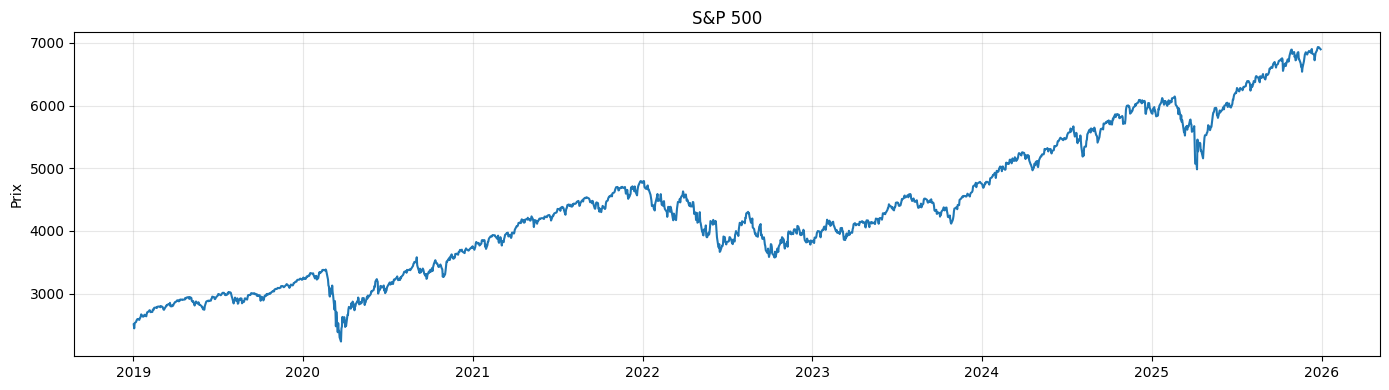

In [6]:
import yfinance as yf

sp500_data = yf.Ticker("^GSPC").history(start="2019-01-01", end="2025-12-31")
sp500_prices = sp500_data['Close'].values
sp500_dates = sp500_data.index
print(f"S&P 500 : {len(sp500_prices)} jours ({sp500_dates[0].strftime('%Y-%m-%d')} -> {sp500_dates[-1].strftime('%Y-%m-%d')})")

plt.figure(figsize=(14, 4))
plt.plot(sp500_dates, sp500_prices)
plt.title("S&P 500"); plt.ylabel("Prix"); plt.tight_layout(); plt.show()

## 11. Calibration et séparation Train/Test

In [7]:
test_start = "2024-01-01"
test_end   = "2025-01-01"

mask_calib = sp500_dates < test_start
mask_test  = (sp500_dates >= test_start) & (sp500_dates < test_end)

prices_calib     = sp500_prices[mask_calib]
prices_test_real = sp500_prices[mask_test]
dates_test_real  = sp500_dates[mask_test]
test_start_idx   = int(np.where(mask_test)[0][0])

dt_real = 1.0 / 252
log_ret_calib = np.diff(np.log(prices_calib))
sigma_calib = np.std(log_ret_calib, ddof=1) / np.sqrt(dt_real)
mu_calib = np.mean(log_ret_calib) / dt_real + 0.5 * sigma_calib**2
r_real = 0.05
rho_calib = (mu_calib - r_real) / sigma_calib

print(f"Calibration : {len(prices_calib)} jours | Test : {len(prices_test_real)} jours")
print(f"mu={mu_calib:.4f} ({mu_calib*100:.1f}%), sigma={sigma_calib:.4f} ({sigma_calib*100:.1f}%)")
print(f"r={r_real}, rho={rho_calib:.4f}, rho^2={rho_calib**2:.4f}")
print(f"Rendement S&P 2024 : {(prices_test_real[-1]/prices_test_real[0]-1)*100:+.1f}%")

Calibration : 1258 jours | Test : 252 jours
mu=0.1516 (15.2%), sigma=0.2141 (21.4%)
r=0.05, rho=0.4746, rho^2=0.2253
Rendement S&P 2024 : +24.0%


## 12. EMV version stable pour données réelles

Le `run_emv` de la Section 4 diverge ici car le ratio de Sharpe calibré ($\rho \approx 0.47$) est modeste comparé aux scénarios de l'article ($\rho = 2.8$ pour $\mu=30\%, \sigma=10\%$). L'algorithme prend des positions extrêmes, $w$ diverge, et tout explose.

**Corrections** :
- **Clip sur $w$** : borné à $[0.5,\, 5]$ (pas de Lagrange négatif ou extrême)
- **Clip sur $u$** : allocations bornées à $[-20,\, 20]$ (pas plus de 20x de levier)
- **Clip sur $x$** : richesse bornée à $[-5,\, 50]$ (pas de valeurs aberrantes)
- **Cible $z = 1.10$** : objectif de $+10\%$, réaliste pour le S&P 500

In [8]:
def run_emv_stable(mu, sigma, r=0.02, x0=1.0, z=1.10, T=1.0, dt=1.0/252,
                   lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
                   mle_window=100, seed=12345,
                   w_clip=(-0.5, 5.0), u_clip=(-20.0, 20.0), x_clip=(-5.0, 50.0)):
    # EMV avec clipping pour stabilite numerique sur donnees reelles
    
    nst = int(round(T / dt))
    rho = (mu - r) / sigma
    rho_sign = 1.0 if rho >= 0 else -1.0
    
    price_rng = np.random.default_rng(seed)
    action_rng = np.random.default_rng(seed + 999)
    
    # Init
    phi1 = -1.0
    theta1 = 0.0
    theta2 = 1.0
    theta3 = rho**2
    phi2 = theta3 / 2.0
    w = z
    theta0 = -theta2*T**2 - theta1*T - (w-z)**2
    
    policy_phi1 = phi1
    policy_phi2 = phi2
    
    xT_list = []
    w_buffer = []
    hist = {k: [] for k in ['phi1','phi2','theta0','theta1','theta2','theta3','w']}
    
    for k in range(M):
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        ep_prices = prices[mle_window-1:]
        
        X = [x0]
        times = [0.0]
        
        for i in range(1, nst+1):
            t_prev = times[-1]
            mean_u, var_u = emv_policy_mean_var(
                policy_phi1, policy_phi2, X[-1], w, t_prev, T, lam, rho_sign)
            u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))
            u_t = float(np.clip(u_t, *u_clip))  # CLIP allocation
            
            x_next = discounted_wealth_step(X[-1], u_t, ep_prices[i-1], ep_prices[i], r, dt)
            x_next = float(np.clip(x_next, *x_clip))  # CLIP richesse
            X.append(x_next)
            times.append(float(i * dt))
            
            vxi  = np.array(X[:-1], dtype=float)
            vxi1 = np.array(X[1:],  dtype=float)
            vti  = np.array(times[:-1], dtype=float)
            vti1 = np.array(times[1:],  dtype=float)
            
            gt1, gt2 = grad_theta_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                     vxi,vxi1,vti,vti1)
            theta1 -= eta_theta * gt1
            theta2 -= eta_theta * gt2
            theta0 = -theta2*T**2 - theta1*T - (w-z)**2
            theta3 = 2*phi2
            
            gp1, gp2 = grad_phi_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                   vxi,vxi1,vti,vti1)
            phi1 -= eta_phi * gp1
            phi2 -= eta_phi * gp2
            phi1 = float(np.clip(phi1, *PHI1_CLIP))
            phi2 = float(np.clip(phi2, *PHI2_CLIP))
        
        policy_phi1 = phi1
        policy_phi2 = phi2
        
        x_T = float(X[-1])
        xT_list.append(x_T)
        w_buffer.append(x_T)
        
        if (k+1) % N == 0:
            w -= alpha * (float(np.mean(w_buffer)) - z)
            w = float(np.clip(w, *w_clip))  # CLIP w
            w_buffer = []
            theta0 = -theta2*T**2 - theta1*T - (w-z)**2
        
        hist['phi1'].append(phi1); hist['phi2'].append(phi2)
        hist['theta0'].append(theta0); hist['theta1'].append(theta1)
        hist['theta2'].append(theta2); hist['theta3'].append(theta3)
        hist['w'].append(w)
    
    return {'xT': np.array(xT_list), **{k: np.array(v) for k,v in hist.items()}}

print("run_emv_stable definie.")

run_emv_stable definie.


## 13. Entraînement

In [9]:
z_real = 1.10    # cible +10% (realiste pour S&P 500)
x0_real = 1.0
T_real = 1.0
M_train = 20000

w_star = compute_w_star(rho_calib, T_real, x0_real, z_real)
print(f"z={z_real}, w*={w_star:.4f}")
print(f"Entrainement EMV stable (M={M_train})...")

t0 = time.time()
emv_sp500 = run_emv_stable(
    mu=mu_calib, sigma=sigma_calib, r=r_real,
    x0=x0_real, z=z_real, T=T_real, dt=dt_real,
    lam=2.0, M=M_train, N=10,
    alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
    mle_window=100, seed=54321,
    w_clip=(0.5, 5.0), u_clip=(-20.0, 20.0), x_clip=(-5.0, 50.0)
)
print(f"Termine en {time.time()-t0:.0f}s")

last2k = emv_sp500['xT'][-2000:]
print(f"E[xT]={last2k.mean():.4f}, Var={last2k.var():.4f}")
print(f"phi1={emv_sp500['phi1'][-1]:.4f}, phi2={emv_sp500['phi2'][-1]:.4f}")
print(f"theta3={emv_sp500['theta3'][-1]:.4f} (rho^2={rho_calib**2:.4f})")
print(f"w={emv_sp500['w'][-1]:.4f} (w*={w_star:.4f})")

z=1.1, w*=1.4958
Entrainement EMV stable (M=20000)...
Termine en 340s
E[xT]=1.0284, Var=0.0039
phi1=-1.6164, phi2=1.0383
theta3=2.0878 (rho^2=0.2253)
w=5.0000 (w*=1.4958)


## 14. Convergence de l'entraînement

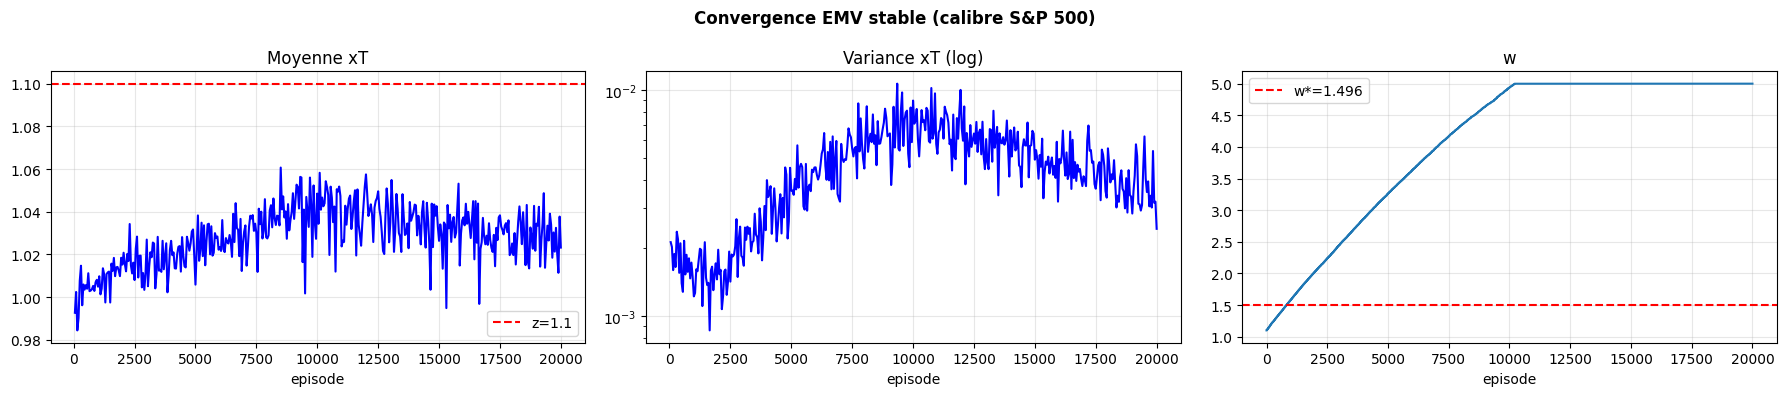

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
xT_tr = emv_sp500['xT']; w50=50; nw=len(xT_tr)//w50
means_tr = [xT_tr[i*w50:(i+1)*w50].mean() for i in range(nw)]
vars_tr  = [xT_tr[i*w50:(i+1)*w50].var()  for i in range(nw)]
ep_ax = np.arange(1, nw+1)*w50

axes[0].plot(ep_ax, means_tr, 'b-')
axes[0].axhline(z_real, color='r', ls='--', label=f'z={z_real}')
axes[0].set_title('Moyenne xT'); axes[0].set_xlabel('episode'); axes[0].legend()

axes[1].semilogy(ep_ax, np.maximum(vars_tr, 1e-8), 'b-')
axes[1].set_title('Variance xT (log)'); axes[1].set_xlabel('episode')

axes[2].plot(emv_sp500['w'])
w_star = compute_w_star(rho_calib, T_real, x0_real, z_real)
axes[2].axhline(w_star, color='r', ls='--', label=f'w*={w_star:.3f}')
axes[2].set_title('w'); axes[2].set_xlabel('episode'); axes[2].legend()

plt.suptitle('Convergence EMV stable (calibre S&P 500)', fontweight='bold')
plt.tight_layout(); plt.show()

## 15. Backtest sur les vrais prix (2024)

In [11]:
def backtest_emv_1year(prices_test, emv_result, r, x0, z, T, dt, rho_sign, seed=42):
    phi1_l = emv_result['phi1'][-1]
    phi2_l = emv_result['phi2'][-1]
    w_l    = emv_result['w'][-1]
    lam = 2.0
    rng = np.random.default_rng(seed)
    
    n = len(prices_test)
    wealth = np.zeros(n); wealth[0] = x0
    allocs = np.zeros(n - 1)
    
    for i in range(n - 1):
        t_i = min(i * dt, T - dt)
        mean_u, var_u = emv_policy_mean_var(phi1_l, phi2_l, wealth[i], w_l, t_i, T, lam, rho_sign)
        u_i = rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))
        u_i = np.clip(u_i, -20, 20)
        
        disc_ret = (prices_test[i+1] * math.exp(-r*dt) / prices_test[i]) - 1.0
        wealth[i+1] = max(wealth[i] + u_i * disc_ret, 0.001)
        allocs[i] = u_i
    
    return wealth, allocs


def backtest_mle_1year(all_prices, test_start_idx, r, x0, z, T, dt, window=100):
    n_test = min(int(round(T/dt)), len(all_prices) - test_start_idx - 1)
    wealth = np.zeros(n_test + 1); wealth[0] = x0
    allocs = np.zeros(n_test)
    
    for i in range(n_test):
        idx = test_start_idx + i
        if idx < window:
            u_i = 0.0
        else:
            wp = all_prices[idx - window + 1 : idx + 1]
            lr = np.diff(np.log(wp))
            if len(lr) < 2:
                u_i = 0.0
            else:
                sh = max(np.std(lr, ddof=1)/np.sqrt(dt), 0.01)
                mh = np.mean(lr)/dt + 0.5*sh**2
                rh = (mh - r)/sh
                rho2T = min(rh**2 * T, 500)
                denom = math.expm1(rho2T)
                wh = (z*math.exp(rho2T)-x0)/denom if abs(denom) > 1e-12 else z
                u_i = np.clip(-((mh-r)/max(sh**2,1e-12))*(wealth[i]-wh), -20, 20)
        
        disc_ret = (all_prices[idx+1]*math.exp(-r*dt)/all_prices[idx]) - 1.0
        wealth[i+1] = max(wealth[i] + u_i * disc_ret, 0.001)
        allocs[i] = u_i
    
    return wealth, allocs


rho_sign_real = 1.0 if rho_calib >= 0 else -1.0

print("Backtest EMV...")
wealth_emv_real, alloc_emv_real = backtest_emv_1year(
    prices_test_real, emv_sp500, r=r_real, x0=x0_real, z=z_real,
    T=T_real, dt=dt_real, rho_sign=rho_sign_real)

print("Backtest MLE...")
wealth_mle_real, alloc_mle_real = backtest_mle_1year(
    sp500_prices, test_start_idx, r=r_real, x0=x0_real, z=z_real,
    T=T_real, dt=dt_real)

n_common = min(len(wealth_emv_real), len(wealth_mle_real), len(prices_test_real))
wealth_bh_real = x0_real * prices_test_real[:n_common] / prices_test_real[0]
wealth_emv_real = wealth_emv_real[:n_common]
wealth_mle_real = wealth_mle_real[:n_common]
dates_plot = dates_test_real[:n_common]
print(f"Backtest sur {n_common} jours")

Backtest EMV...
Backtest MLE...
Backtest sur 252 jours


## 16. Résultats

In [12]:
def print_stats(wealth, name, dt=1.0/252):
    n = len(wealth)
    total_ret = wealth[-1]/wealth[0] - 1
    n_years = max(n*dt, 0.01)
    ann_ret = (1+total_ret)**(1/n_years) - 1
    dr = np.diff(wealth)/np.maximum(wealth[:-1], 1e-12)
    ann_vol = np.std(dr)*np.sqrt(252)
    sr = ann_ret/ann_vol if ann_vol > 1e-12 else 0
    mdd = np.max(1 - wealth/np.maximum.accumulate(wealth))
    print(f"  {name:>12s} | Rend={total_ret*100:+6.1f}% | Vol={ann_vol*100:5.1f}% | "
          f"SR={sr:5.2f} | MaxDD={mdd*100:5.1f}% | Final={wealth[-1]:.4f}")

print("=" * 100)
print(f"BACKTEST S&P 500 : {dates_plot[0].strftime('%Y-%m-%d')} -> {dates_plot[-1].strftime('%Y-%m-%d')}")
print(f"Cible z = {z_real} (+{(z_real-1)*100:.0f}%)")
print("=" * 100)
print_stats(wealth_emv_real, "EMV (RL)")
print_stats(wealth_mle_real, "MLE")
print_stats(wealth_bh_real, "Buy & Hold")
print("=" * 100)

BACKTEST S&P 500 : 2024-01-02 -> 2024-12-31
Cible z = 1.1 (+10%)
      EMV (RL) | Rend=  +5.6% | Vol=  3.5% | SR= 1.61 | MaxDD=  2.7% | Final=1.0558
           MLE | Rend= -31.1% | Vol= 79.5% | SR=-0.39 | MaxDD= 65.2% | Final=0.6894
    Buy & Hold | Rend= +24.0% | Vol= 12.6% | SR= 1.90 | MaxDD=  8.5% | Final=1.2401


## 17. Visualisations

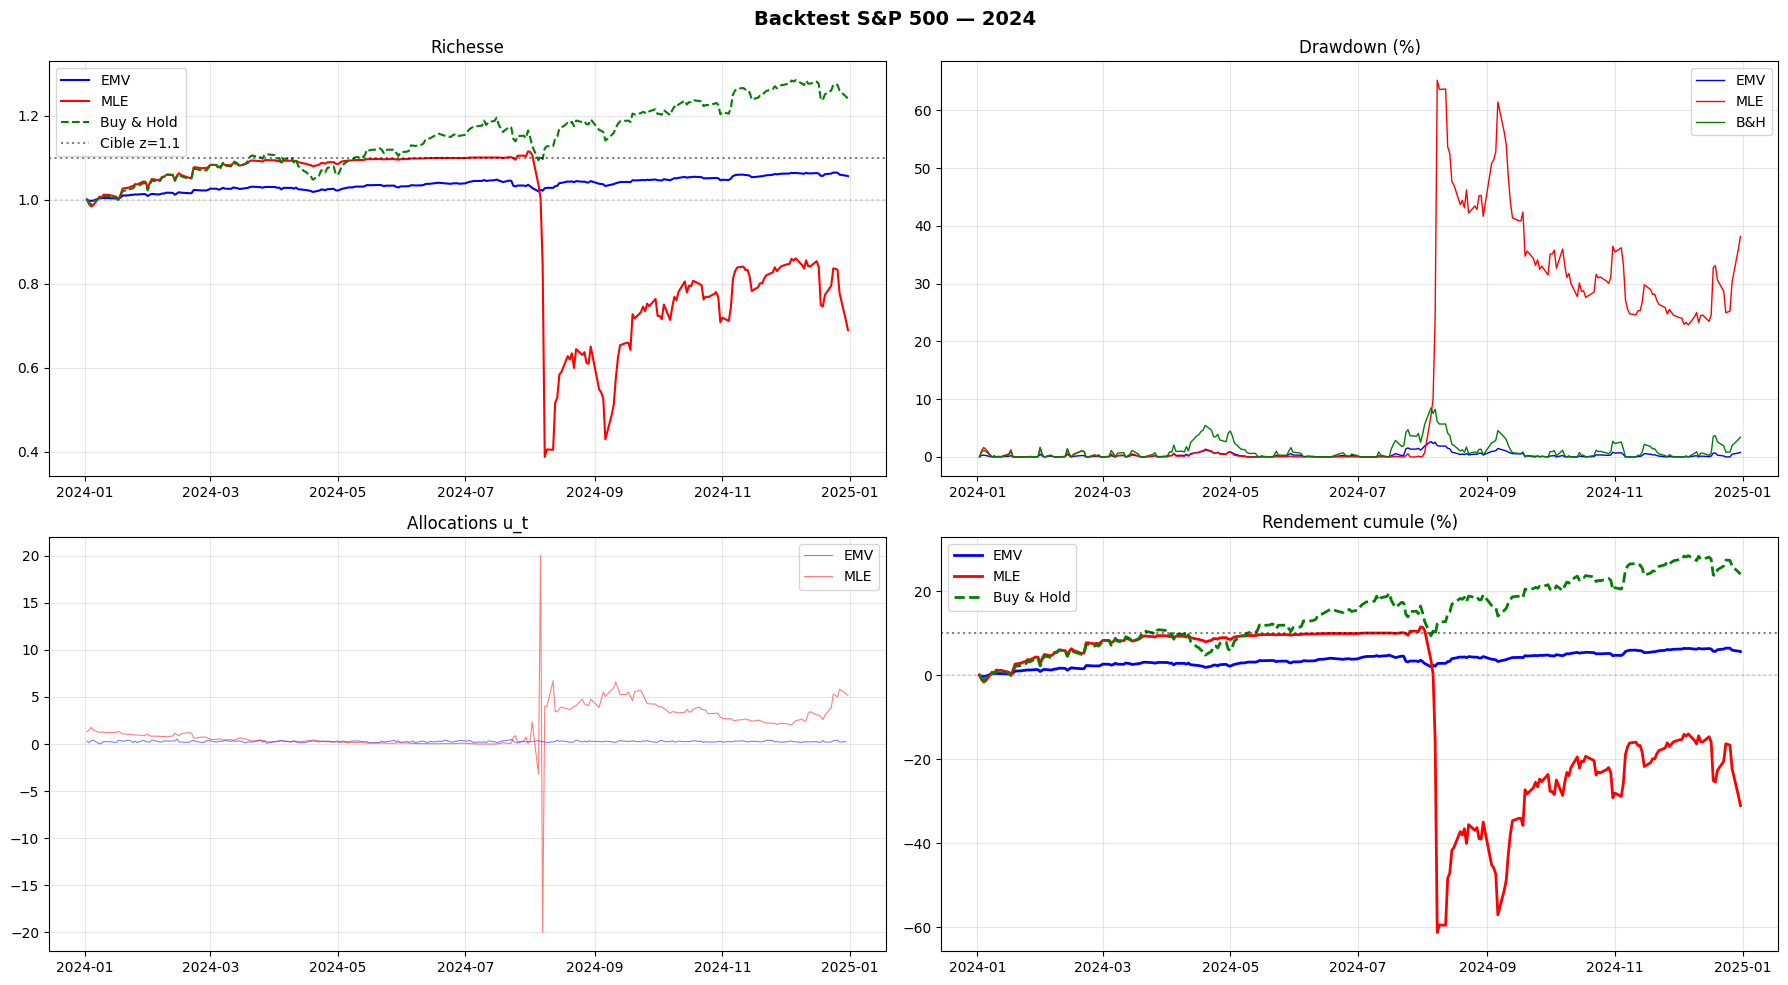

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

ax = axes[0,0]
ax.plot(dates_plot, wealth_emv_real, 'b-', lw=1.5, label='EMV')
ax.plot(dates_plot, wealth_mle_real, 'r-', lw=1.5, label='MLE')
ax.plot(dates_plot, wealth_bh_real, 'g--', lw=1.5, label='Buy & Hold')
ax.axhline(z_real, color='k', ls=':', alpha=0.5, label=f'Cible z={z_real}')
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.set_title('Richesse'); ax.legend()

ax = axes[0,1]
for w_arr,nm,col in [(wealth_emv_real,'EMV','b'),(wealth_mle_real,'MLE','r'),(wealth_bh_real,'B&H','g')]:
    dd = 1 - w_arr/np.maximum.accumulate(w_arr)
    ax.plot(dates_plot, dd*100, color=col, lw=1, label=nm)
ax.set_title('Drawdown (%)'); ax.legend()

ax = axes[1,0]
ax.plot(dates_plot[:-1], alloc_emv_real, 'b-', alpha=0.5, lw=0.8, label='EMV')
ax.plot(dates_plot[:len(alloc_mle_real)], alloc_mle_real, 'r-', alpha=0.5, lw=0.8, label='MLE')
ax.set_title('Allocations u_t'); ax.legend()

ax = axes[1,1]
ax.plot(dates_plot, (wealth_emv_real/x0_real-1)*100, 'b-', lw=2, label='EMV')
ax.plot(dates_plot, (wealth_mle_real/x0_real-1)*100, 'r-', lw=2, label='MLE')
ax.plot(dates_plot, (wealth_bh_real/x0_real-1)*100, 'g--', lw=2, label='Buy & Hold')
ax.axhline((z_real-1)*100, color='k', ls=':', alpha=0.5)
ax.axhline(0, color='gray', ls=':', alpha=0.3)
ax.set_title('Rendement cumule (%)'); ax.legend()

plt.suptitle(f'Backtest S&P 500 — {dates_plot[0].strftime("%Y")}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 18. Interprétation

### Pourquoi le `run_emv` original divergeait

Le ratio de Sharpe calibré sur le S&P 500 ($\rho \approx 0.47$) est bien plus faible que dans les scénarios de l'article qui fonctionnent ($\rho = 2.8$ pour $\mu=30\%, \sigma=10\%$). Avec un faible $\rho$, la politique prend des positions importantes pour atteindre la cible $z$, et les allocations stochastiques (exploration gaussienne) génèrent des $x_T$ extrêmes, ce qui fait diverger $w$ par feedback positif.

### Limites de l'approche
1. L'EMV est conçu pour un **GBM** avec paramètres constants. Le S&P 500 réel viole cette hypothèse (queues épaisses, clustering de volatilité).
2. Le clipping introduit un **biais** : on contraint artificiellement les paramètres, ce qui peut éloigner la solution de l'optimum théorique.
3. Les paramètres calibrés 2019–2023 ne sont pas forcément représentatifs de 2024.